In [1]:
# Google Colab already has pandas, numpy, matplotlib, seaborn, scikit-learn and torch.
# Only the "datasets" library has to be installed.
# (On your own computer you can run:  pip install -r requirements.txt)
%pip install -q datasets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

# folders where I will save things
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

Using device: cpu


In [3]:
from datasets import load_dataset

raw_data = load_dataset("zeroshot/twitter-financial-news-sentiment")
print(raw_data)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})


In [4]:
train_df = raw_data["train"].to_pandas()
val_df = raw_data["validation"].to_pandas()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

train_df.to_csv("data/train_raw.csv", index=False)
val_df.to_csv("data/validation_raw.csv", index=False)

Train shape: (9543, 2)
Validation shape: (2388, 2)


In [5]:
label_map = {0: "Bearish", 1: "Bullish", 2: "Neutral"}

train_df["sentiment"] = train_df["label"].map(label_map)
val_df["sentiment"] = val_df["label"].map(label_map)

print(train_df.head(10))

                                                text  label sentiment
0  $BYND - JPMorgan reels in expectations on Beyo...      0   Bearish
1  $CCL $RCL - Nomura points to bookings weakness...      0   Bearish
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...      0   Bearish
3  $ESS: BTIG Research cuts to Neutral https://t....      0   Bearish
4  $FNKO - Funko slides after Piper Jaffray PT cu...      0   Bearish
5  $FTI - TechnipFMC downgraded at Berenberg but ...      0   Bearish
6      $GM - GM loses a bull https://t.co/tdUfG5HbXy      0   Bearish
7  $GM: Deutsche Bank cuts to Hold https://t.co/7...      0   Bearish
8                 $GTT: Cowen cuts to Market Perform      0   Bearish
9  $HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...      0   Bearish


In [6]:
print("Train class counts:")
print(train_df["sentiment"].value_counts())
print()
print("Validation class counts:")
print(val_df["sentiment"].value_counts())

Train class counts:
sentiment
Neutral    6178
Bullish    1923
Bearish    1442
Name: count, dtype: int64

Validation class counts:
sentiment
Neutral    1566
Bullish     475
Bearish     347
Name: count, dtype: int64


In [7]:
print("Missing values in train:")
print(train_df.isnull().sum())
print()
print("Empty texts in train:", (train_df["text"].str.strip() == "").sum())
print("Empty texts in validation:", (val_df["text"].str.strip() == "").sum())
print("Duplicate texts in train:", train_df["text"].duplicated().sum())
print("Duplicate texts in validation:", val_df["text"].duplicated().sum())

Missing values in train:
text         0
label        0
sentiment    0
dtype: int64

Empty texts in train: 0
Empty texts in validation: 0
Duplicate texts in train: 0
Duplicate texts in validation: 0


In [8]:
common_texts = set(train_df["text"]).intersection(set(val_df["text"]))
print("Tweets present in both train and validation:", len(common_texts))

Tweets present in both train and validation: 0


In [9]:
def clean_text(text):
    text = str(text)

    # remove links
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # remove @mentions
    text = re.sub(r"@\w+", " ", text)
    # remove html tags
    text = re.sub(r"<[^>]+>", " ", text)
    # remove the source hashtag that appears in this dataset
    text = re.sub(r"#MarketScreener\b", " ", text, flags=re.IGNORECASE)

    # fix some broken characters (encoding problems)
    bad_chars = {
        "\u00e2\u0080\u0099": "'",
        "\u00e2\u0080\u009c": '"',
        "\u00e2\u0080\u009d": '"',
        "\u00e2\u0080\u0093": "-",
        "\u00e2\u0080\u0094": "-",
        "\u00c2\u00a0": " ",
    }
    for bad, good in bad_chars.items():
        text = text.replace(bad, good)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [10]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)

for i in range(3):
    print("BEFORE:", train_df.loc[i, "text"])
    print("AFTER :", train_df.loc[i, "clean_text"])
    print("-" * 80)

BEFORE: $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
AFTER : $BYND - JPMorgan reels in expectations on Beyond Meat
--------------------------------------------------------------------------------
BEFORE: $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3
AFTER : $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean
--------------------------------------------------------------------------------
BEFORE: $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb
AFTER : $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook
--------------------------------------------------------------------------------


In [11]:
train_before = len(train_df)
val_before = len(val_df)

train_df = train_df[train_df["clean_text"] != ""].reset_index(drop=True)
val_df = val_df[val_df["clean_text"] != ""].reset_index(drop=True)

print("Rows removed from train:", train_before - len(train_df))
print("Rows removed from validation:", val_before - len(val_df))
print("Final train shape:", train_df.shape)
print("Final validation shape:", val_df.shape)

train_df.to_csv("data/train_clean.csv", index=False)
val_df.to_csv("data/validation_clean.csv", index=False)

Rows removed from train: 6
Rows removed from validation: 0
Final train shape: (9537, 4)
Final validation shape: (2388, 4)


In [12]:
train_df["word_count"] = train_df["clean_text"].str.split().str.len()
train_df["char_count"] = train_df["clean_text"].str.len()

print(train_df[["word_count", "char_count"]].describe())

        word_count   char_count
count  9537.000000  9537.000000
mean     11.596309    71.788508
std       4.400653    26.016681
min       1.000000     2.000000
25%       8.000000    53.000000
50%      11.000000    67.000000
75%      14.000000    91.000000
max      31.000000   190.000000


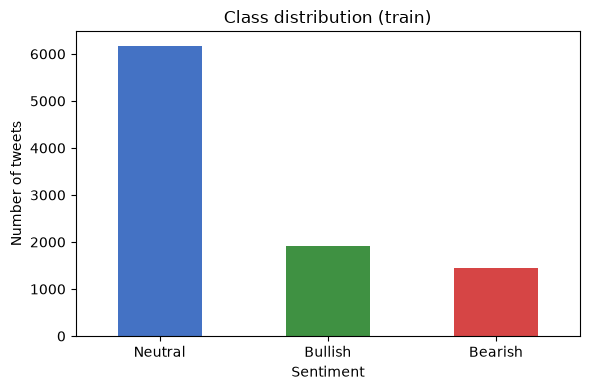

In [13]:
plt.figure(figsize=(6, 4))
train_df["sentiment"].value_counts().plot(kind="bar", color=["#4472c4", "#3f9142", "#d64545"])
plt.title("Class distribution (train)")
plt.xlabel("Sentiment")
plt.ylabel("Number of tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("data/class_distribution.png", dpi=120)
plt.show()

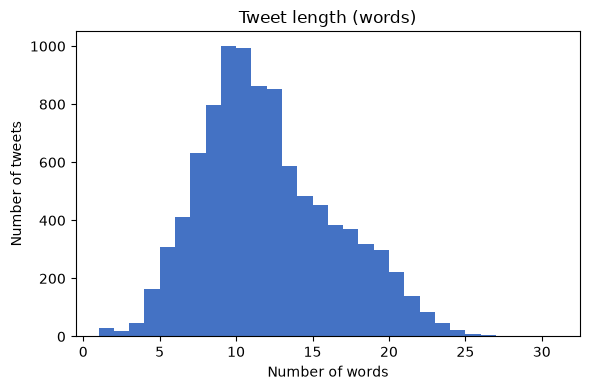

In [14]:
plt.figure(figsize=(6, 4))
plt.hist(train_df["word_count"], bins=30, color="#4472c4")
plt.title("Tweet length (words)")
plt.xlabel("Number of words")
plt.ylabel("Number of tweets")
plt.tight_layout()
plt.savefig("data/word_count_hist.png", dpi=120)
plt.show()

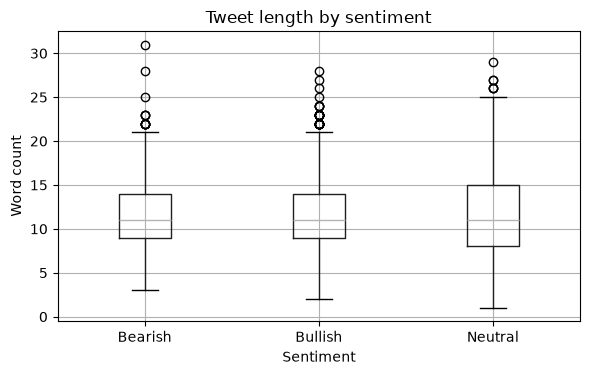

In [15]:
train_df.boxplot(column="word_count", by="sentiment", figsize=(6, 4))
plt.title("Tweet length by sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Word count")
plt.tight_layout()
plt.savefig("data/word_count_by_sentiment.png", dpi=120)
plt.show()

In [16]:
def get_words(text):
    return re.findall(r"\$?[A-Za-z]+(?:[-'][A-Za-z]+)*", text.lower())

all_text = " ".join(train_df["clean_text"])
word_counter = Counter(get_words(all_text))

print("Total words:", sum(word_counter.values()))
print("Unique words:", len(word_counter))
print()
print("Top 15 words:")
for word, count in word_counter.most_common(15):
    print(word, count)

tickers = re.findall(r"\$[A-Za-z]+", all_text)
ticker_counter = Counter([t.upper() for t in tickers])
print()
print("Unique tickers:", len(ticker_counter))
print("Top 10 tickers:")
for ticker, count in ticker_counter.most_common(10):
    print(ticker, count)

Total words: 106200
Unique words: 16068

Top 15 words:
to 2652
the 2559
of 1676
in 1616
a 1412
on 1367
for 1221
s 1088
and 1029
stock 974
is 868
at 664
as 608
with 501
after 490

Unique tickers: 1213
Top 10 tickers:
$SPY 26
$COMDX 23
$TSLA 20
$SCANX 16
$SUMRX 13
$NVDA 12
$USO 12
$MDCO 11
$ECONX 11
$AAPL 10


In [17]:
PAD = "<pad>"   # used to fill short tweets
UNK = "<unk>"   # used for words that are not in the vocabulary
MAX_LEN = 40    # every tweet will be exactly 40 tokens (the longest tweet is only ~31 words)

def tokenize(text):
    # keeps tickers like $AAPL as one token
    return re.findall(r"\$?[A-Za-z]+(?:[-'][A-Za-z]+)*|\d+", text.lower())

# count words in the TRAIN data only
counter = Counter()
for text in train_df["clean_text"]:
    counter.update(tokenize(text))

# keep only words that appear at least 2 times
vocab = {PAD: 0, UNK: 1}
for word, freq in counter.most_common(15000):
    if freq >= 2:
        vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 7500


In [18]:
def text_to_ids(text, vocab, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids = []
    for t in tokens:
        ids.append(vocab.get(t, vocab[UNK]))
    ids = ids[:max_len]                          # cut if too long
    ids = ids + [vocab[PAD]] * (max_len - len(ids))   # pad if too short
    return ids

print(train_df.loc[0, "clean_text"])
print(text_to_ids(train_df.loc[0, "clean_text"], vocab))

$BYND - JPMorgan reels in expectations on Beyond Meat
[4957, 833, 4958, 5, 379, 7, 876, 1297, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [19]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        ids = text_to_ids(self.texts[index], self.vocab)
        x = torch.tensor(ids, dtype=torch.long)
        y = torch.tensor(self.labels[index], dtype=torch.long)
        return x, y


BATCH_SIZE = 64

train_data = TweetDataset(train_df["clean_text"], train_df["label"], vocab)
val_data = TweetDataset(val_df["clean_text"], val_df["label"], vocab)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

# check one batch
xb, yb = next(iter(train_loader))
print("Input batch shape:", xb.shape)
print("Label batch shape:", yb.shape)

Input batch shape: torch.Size([64, 40])
Label batch shape: torch.Size([64])


In [20]:
class SentimentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=3, rnn_type="lstm", dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        if rnn_type == "rnn":
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif rnn_type == "lstm":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        else:
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        output, hidden = self.rnn(x)

        # LSTM returns (h, c), the others return only h
        if isinstance(hidden, tuple):
            hidden = hidden[0]

        last = hidden[-1]          # hidden state of the last step
        last = self.dropout(last)
        return self.fc(last)

In [21]:
for t in ["rnn", "lstm", "gru"]:
    test_model = SentimentModel(len(vocab), rnn_type=t).to(device)
    out = test_model(xb.to(device))
    print(t, "output shape:", tuple(out.shape))

rnn output shape: (64, 3)
lstm output shape: (64, 3)
gru output shape: (64, 3)


In [22]:
def evaluate(model, loader):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            total_loss += loss.item() * x.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    result = {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "preds": all_preds,
        "labels": all_labels,
    }
    return result

In [23]:
def train(model, train_loader, val_loader, epochs=15, lr=1e-3, patience=3, name="model"):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    best_f1 = -1
    best_weights = None
    no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item() * x.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val["loss"])
        history["val_acc"].append(val["accuracy"])
        history["val_f1"].append(val["macro_f1"])

        print(f"[{name}] epoch {epoch:2d} | train loss {train_loss:.4f} | val loss {val['loss']:.4f} | "
              f"val acc {val['accuracy']:.4f} | val macro F1 {val['macro_f1']:.4f}")

        # early stopping check
        if val["macro_f1"] > best_f1:
            best_f1 = val["macro_f1"]
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"[{name}] early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_weights)
    return model, history

In [24]:
EMBED_DIM = 100
HIDDEN_DIM = 128
NUM_CLASSES = 3

models = {}
histories = {}
results = {}

for rnn_type in ["rnn", "lstm", "gru"]:
    print("=" * 80)
    print("Training", rnn_type.upper())
    print("=" * 80)

    model = SentimentModel(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, rnn_type)
    model, history = train(model, train_loader, val_loader, epochs=15, lr=1e-3, patience=3, name=rnn_type.upper())

    models[rnn_type] = model
    histories[rnn_type] = history
    results[rnn_type] = evaluate(model, val_loader)
    print()

Training RNN
[RNN] epoch  1 | train loss 0.9054 | val loss 0.8823 | val acc 0.6558 | val macro F1 0.2640
[RNN] epoch  2 | train loss 0.8952 | val loss 0.8784 | val acc 0.6558 | val macro F1 0.2640
[RNN] epoch  3 | train loss 0.8945 | val loss 0.8788 | val acc 0.6558 | val macro F1 0.2640
[RNN] epoch  4 | train loss 0.8955 | val loss 0.8784 | val acc 0.6558 | val macro F1 0.2640
[RNN] early stopping at epoch 4

Training LSTM
[LSTM] epoch  1 | train loss 0.9098 | val loss 0.8819 | val acc 0.6558 | val macro F1 0.2640
[LSTM] epoch  2 | train loss 0.8708 | val loss 0.7714 | val acc 0.6633 | val macro F1 0.4112
[LSTM] epoch  3 | train loss 0.7302 | val loss 0.7196 | val acc 0.7039 | val macro F1 0.4169
[LSTM] epoch  4 | train loss 0.6428 | val loss 0.7061 | val acc 0.7316 | val macro F1 0.4720
[LSTM] epoch  5 | train loss 0.5863 | val loss 0.6801 | val acc 0.7261 | val macro F1 0.4789
[LSTM] epoch  6 | train loss 0.5244 | val loss 0.6471 | val acc 0.7366 | val macro F1 0.5233
[LSTM] epoch  

In [25]:
compare_df = pd.DataFrame({
    "Model": [name.upper() for name in results],
    "Val Accuracy": [results[name]["accuracy"] for name in results],
    "Val Macro F1": [results[name]["macro_f1"] for name in results],
})
compare_df = compare_df.sort_values("Val Macro F1", ascending=False).reset_index(drop=True)
print(compare_df)

  Model  Val Accuracy  Val Macro F1
0  LSTM      0.790201      0.702448
1   GRU      0.785595      0.674397
2   RNN      0.655779      0.264036


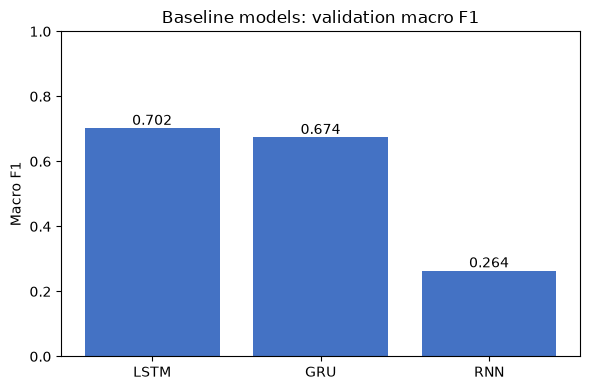

In [26]:
plt.figure(figsize=(6, 4))
plt.bar(compare_df["Model"], compare_df["Val Macro F1"], color="#4472c4")
plt.title("Baseline models: validation macro F1")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
for i, v in enumerate(compare_df["Val Macro F1"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig("data/baseline_comparison.png", dpi=120)
plt.show()

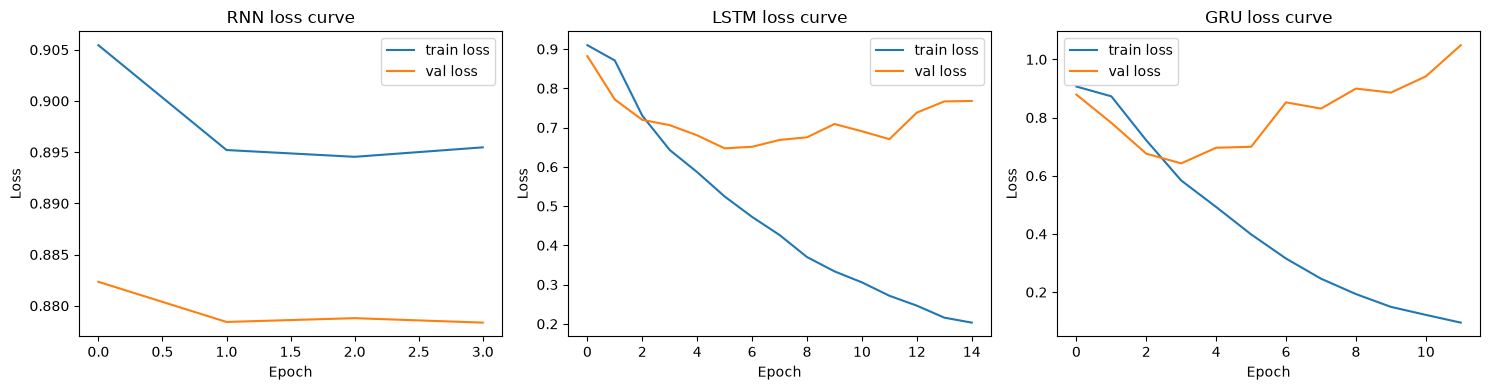

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, histories):
    ax.plot(histories[name]["train_loss"], label="train loss")
    ax.plot(histories[name]["val_loss"], label="val loss")
    ax.set_title(name.upper() + " loss curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
plt.tight_layout()
plt.savefig("data/loss_curves.png", dpi=120)
plt.show()

In [28]:
class_names = ["Bearish", "Bullish", "Neutral"]

for name in results:
    print("=" * 60)
    print(name.upper())
    print(classification_report(results[name]["labels"], results[name]["preds"],
                                target_names=class_names, zero_division=0))

RNN
              precision    recall  f1-score   support

     Bearish       0.00      0.00      0.00       347
     Bullish       0.00      0.00      0.00       475
     Neutral       0.66      1.00      0.79      1566

    accuracy                           0.66      2388
   macro avg       0.22      0.33      0.26      2388
weighted avg       0.43      0.66      0.52      2388

LSTM
              precision    recall  f1-score   support

     Bearish       0.53      0.58      0.56       347
     Bullish       0.74      0.62      0.68       475
     Neutral       0.86      0.89      0.88      1566

    accuracy                           0.79      2388
   macro avg       0.71      0.70      0.70      2388
weighted avg       0.79      0.79      0.79      2388

GRU
              precision    recall  f1-score   support

     Bearish       0.54      0.52      0.53       347
     Bullish       0.72      0.53      0.61       475
     Neutral       0.85      0.92      0.88      1566

    acc

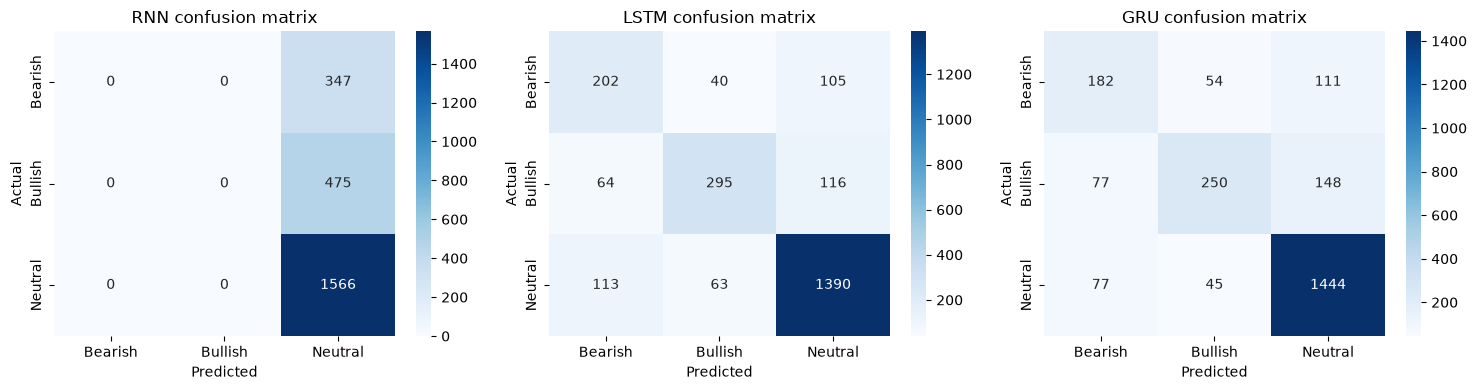

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, results):
    cm = confusion_matrix(results[name]["labels"], results[name]["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(name.upper() + " confusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("data/confusion_matrices.png", dpi=120)
plt.show()

In [30]:
best_name = compare_df.iloc[0]["Model"].lower()
best_result = results[best_name]

error_df = val_df.copy()
error_df["predicted"] = [label_map[p] for p in best_result["preds"]]
error_df = error_df[error_df["sentiment"] != error_df["predicted"]]

print("Number of mistakes of", best_name.upper(), ":", len(error_df))
print()
for i, row in error_df.head(8).iterrows():
    print("TEXT     :", row["clean_text"])
    print("ACTUAL   :", row["sentiment"], "| PREDICTED:", row["predicted"])
    print()

Number of mistakes of LSTM : 501

TEXT     : $ALLY - Ally Financial pulls outlook
ACTUAL   : Bearish | PREDICTED: Neutral

TEXT     : $PRTY - Moody's turns negative on Party City
ACTUAL   : Bearish | PREDICTED: Neutral

TEXT     : Analysts Eviscerate Musk's Cybertruck: "0% Of Responses Felt It Will Be A Success"
ACTUAL   : Bearish | PREDICTED: Neutral

TEXT     : Barclays assigns only a 20% chance that studies on a Gilead antiviral drug being done in China will succeed against…
ACTUAL   : Bearish | PREDICTED: Neutral

TEXT     : BTIG points to breakfast pressure for Dunkin' Brands
ACTUAL   : Bearish | PREDICTED: Neutral

TEXT     : Downgrades 4/7: $AAN $BDN $BECN $BTE $CDEV $CHK $COOP $CPE $CVA $DAN $DOC $DRH $EPR $ESRT $ETM $FAST $FBM $GM $GMS…
ACTUAL   : Bearish | PREDICTED: Bullish

TEXT     : Okta -2% on valuation downgrade
ACTUAL   : Bearish | PREDICTED: Bullish

TEXT     : $ENR - Energizer shakes off JPMorgan's bear call
ACTUAL   : Bullish | PREDICTED: Bearish



In [31]:
print("Best baseline model:", best_name.upper(), "| macro F1:", round(compare_df.iloc[0]["Val Macro F1"], 4))

torch.save(models[best_name].state_dict(), "models/best_baseline_model.pt")

config = {
    "vocab_size": len(vocab),
    "embed_dim": EMBED_DIM,
    "hidden_dim": HIDDEN_DIM,
    "num_classes": NUM_CLASSES,
    "rnn_type": best_name,
    "max_len": MAX_LEN,
}
with open("models/model_config.json", "w") as f:
    json.dump(config, f, indent=2)

with open("models/vocab.json", "w") as f:
    json.dump(vocab, f)

print("Saved files in the models/ folder")

Best baseline model: LSTM | macro F1: 0.7024
Saved files in the models/ folder


In [32]:
print(compare_df)
compare_df.to_csv("data/model_comparison.csv", index=False)

best_row = compare_df.iloc[0]
rnn_row = compare_df[compare_df["Model"] == "RNN"].iloc[0]

print()
print("Best model:", best_row["Model"], "with macro F1 =", round(best_row["Val Macro F1"], 4))
print("Simple RNN macro F1 =", round(rnn_row["Val Macro F1"], 4))
print("Improvement over the simple RNN:", round(best_row["Val Macro F1"] - rnn_row["Val Macro F1"], 4))

  Model  Val Accuracy  Val Macro F1
0  LSTM      0.790201      0.702448
1   GRU      0.785595      0.674397
2   RNN      0.655779      0.264036

Best model: LSTM with macro F1 = 0.7024
Simple RNN macro F1 = 0.264
Improvement over the simple RNN: 0.4384


In [33]:
def predict_paragraph(paragraph, model, vocab):
    model.eval()
    sentences = re.split(r"(?<=[.!?])\s+", paragraph.strip())
    sentences = [s for s in sentences if s.strip() != ""]

    all_probs = []
    for sentence in sentences:
        ids = text_to_ids(clean_text(sentence), vocab)
        x = torch.tensor([ids], dtype=torch.long).to(device)
        with torch.no_grad():
            probs = torch.softmax(model(x), dim=1)[0].cpu().numpy()
        all_probs.append(probs)

    avg_probs = np.mean(all_probs, axis=0)
    best_id = int(np.argmax(avg_probs))
    return label_map[best_id], {label_map[i]: float(avg_probs[i]) for i in range(3)}


text = "Shares of the company surge after record quarterly profit. Analysts raise their price targets."
label, probs = predict_paragraph(text, models[best_name], vocab)
print("Paragraph:", text)
print("Sentiment:", label)
print("Probabilities:", probs)

Paragraph: Shares of the company surge after record quarterly profit. Analysts raise their price targets.
Sentiment: Neutral
Probabilities: {'Bearish': 0.27926620841026306, 'Bullish': 0.07191390544176102, 'Neutral': 0.6488198637962341}


In [34]:
my_texts = [
    "$TSLA - Tesla upgraded to Buy at Goldman, price target raised.",
    "$AAPL - Apple downgraded at Morgan Stanley on weak iPhone demand.",
    "$MSFT to report quarterly earnings on Tuesday after the close.",
    "Shares surged after record quarterly profit. Analysts raised their targets. "
    "However the CFO warned about weaker demand next year.",
]

for t in my_texts:
    label, probs = predict_paragraph(t, models[best_name], vocab)
    print("TEXT     :", t)
    print("SENTIMENT:", label)
    print("PROBS    :", {k: round(v, 3) for k, v in probs.items()})
    print()

TEXT     : $TSLA - Tesla upgraded to Buy at Goldman, price target raised.
SENTIMENT: Bullish
PROBS    : {'Bearish': 0.002, 'Bullish': 0.991, 'Neutral': 0.007}

TEXT     : $AAPL - Apple downgraded at Morgan Stanley on weak iPhone demand.
SENTIMENT: Bearish
PROBS    : {'Bearish': 0.832, 'Bullish': 0.044, 'Neutral': 0.124}

TEXT     : $MSFT to report quarterly earnings on Tuesday after the close.
SENTIMENT: Bearish
PROBS    : {'Bearish': 0.942, 'Bullish': 0.016, 'Neutral': 0.042}

TEXT     : Shares surged after record quarterly profit. Analysts raised their targets. However the CFO warned about weaker demand next year.
SENTIMENT: Bullish
PROBS    : {'Bearish': 0.006, 'Bullish': 0.664, 'Neutral': 0.33}



In [35]:
import zipfile

with zipfile.ZipFile("saved_results.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in ["models", "data"]:
        for root, dirs, files_in_folder in os.walk(folder):
            for file_name in files_in_folder:
                zf.write(os.path.join(root, file_name))

print("Created saved_results.zip")

try:
    from google.colab import files
    files.download("saved_results.zip")      # only works on Google Colab
except ImportError:
    print("Not on Colab, the zip file is in the project folder.")

Created saved_results.zip
Not on Colab, the zip file is in the project folder.
